In [ ]:
import pandas as pd

preprocessing data

In [ ]:
df = pd.read_csv("../data/raw/uk_politics_20260215.csv")
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   title   274 non-null    str  
 1   text    274 non-null    str  
 2   source  274 non-null    str  
 3   date    274 non-null    str  
 4   label   274 non-null    str  
dtypes: str(5)
memory usage: 10.8 KB


In [ ]:
df2 = pd.read_csv("../data/raw/uk_fake_satire_20260301.csv")
df2.head()
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   title   92 non-null     str  
 1   text    92 non-null     str  
 2   source  92 non-null     str  
 3   date    92 non-null     str  
 4   label   92 non-null     int64
dtypes: int64(1), str(4)
memory usage: 3.7 KB


In [ ]:
# step 1 - standardize the labels
# real news = 0, fake news = 1

df['label'] = 0
df2['label'] = 1

In [ ]:

#step 2 - balancing the dataset
min_samples = len(df2)

# randomly sample exactly 92 rows from real dataset
df_real_balanced = df.sample(n=min_samples, random_state=42)


In [ ]:
# step 3 - combining and shuffling the dataset
# Concatenate the balanced Real news and all the Fake news

df_combined = pd.concat([df_real_balanced, df2], ignore_index=True)

# Shuffle the rows completely so the model doesn't learn the order
df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)

feature extraction (before baseline model training)

In [ ]:
%pip install textblob

In [ ]:
import pandas as pd
import re
from textblob import TextBlob

# Load the balanced dataset you saved in the last step
# df = pd.read_csv("../data/raw/uk_balanced_baseline_data.csv")

def extract_style_features(text):
    # Handle empty text just in case
    if not isinstance(text, str) or len(text) == 0:
        return pd.Series([0, 0, 0, 0, 0, 0])
    
    # 1. Word Count
    words = text.split()
    word_count = len(words)
    if word_count == 0:
        return pd.Series([0, 0, 0, 0, 0, 0])

    # 2. Shout Ratio (Percentage of ALL CAPS words)
    # We look for words with 2 or more uppercase letters (to ignore "I" or "A")
    caps_words = [word for word in words if word.isupper() and len(word) > 1]
    shout_ratio = len(caps_words) / word_count

    # 3. Punctuation Density (Exclamation and Question marks)
    exclamations = text.count('!')
    questions = text.count('?')
    exclamation_density = exclamations / word_count
    question_density = questions / word_count

    # 4. Lexical Diversity (Unique words divided by total words)
    # Fake news often repeats the same simple words. Real news uses a wider vocabulary.
    unique_words = len(set([w.lower() for w in words]))
    lexical_diversity = unique_words / word_count

    # 5. Sentiment Polarity (-1.0 to 1.0)
    # Negative = angry/fearful, Positive = happy/optimistic
    blob = TextBlob(text)
    sentiment = blob.sentiment.polarity

    return pd.Series([
        word_count, 
        shout_ratio, 
        exclamation_density, 
        question_density, 
        lexical_diversity, 
        sentiment
    ])

print("Extracting stylistic features... this might take a minute...")

# Apply the function to create new columns
df_combined[['word_count', 'shout_ratio', 'exclamation_density', 'question_density', 'lexical_diversity', 'sentiment']] = df_combined['text'].apply(extract_style_features)

print("--- Feature Extraction Complete ---")

# Let's look at the average differences between Real (0) and Fake (1)
print("\nMean Feature Values by Class:")
print(df_combined.groupby('label')[['word_count', 'shout_ratio', 'question_density', 'exclamation_density', 'lexical_diversity', 'sentiment']].mean())

# Save this new dataset 
df_combined.to_csv("../data/processed/uk_features_extracted.csv", index=False)
print("\nSaved to: ../data/processed/uk_features_extracted.csv")

In [ ]:
# step 4 - basic text cleaning
# Ensure all text is treated as strings and converted to lowercase
df_combined['text'] = df_combined['text'].astype(str).str.lower()

In [ ]:
# step 5 - verify the final dataset

print("--- Preprocessing Complete ---")
print(f"Total rows: {len(df_combined)}")
print("\nClass Distribution:")
print(df_combined['label'].value_counts())

--- Preprocessing Complete ---
Total rows: 184

Class Distribution:
label
0    92
1    92
Name: count, dtype: int64


In [ ]:
# save the cleaned and balanced dataset

df_combined.to_csv("../data/raw/uk_balanced_baseline_data.csv", index=False)
print("\nSaved to: ../data/raw/uk_balanced_baseline_data.csv")


Saved to: ../data/raw/uk_balanced_baseline_data.csv


Baseline Model training

=== BASELINE MODEL PERFORMANCE ===

Overall Accuracy: 91.89%

--- Classification Report ---
              precision    recall  f1-score   support

    Real (0)       0.88      0.94      0.91        16
    Fake (1)       0.95      0.90      0.93        21

    accuracy                           0.92        37
   macro avg       0.92      0.92      0.92        37
weighted avg       0.92      0.92      0.92        37



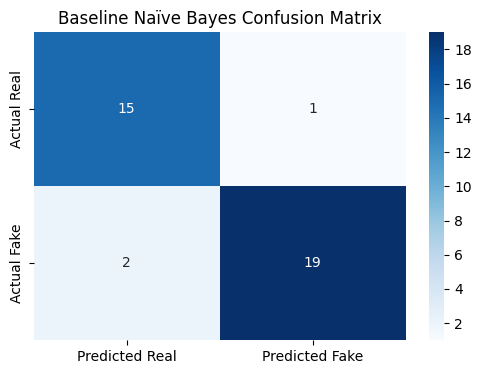

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# --- STEP 1: DEFINE FEATURES (X) AND LABELS (y) ---
X = df_combined['text']
y = df_combined['label']

# --- STEP 2: TRAIN/TEST SPLIT ---
# 80% of the data to train the model, 20% to test .

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- STEP 3: TEXT VECTORIZATION (TF-IDF) ---
# convert words into a matrix of numbers.
#  remove  English stop words
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test) # Note: We only 'transform' the test set to prevent data leakage

# --- STEP 4: MODEL TRAINING ---
# Initialize and train the Naïve Bayes classifier
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

# --- STEP 5: PREDICTION & EVALUATION ---
y_pred = nb_model.predict(X_test_vec)

print("=== BASELINE MODEL PERFORMANCE ===\n")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

print("--- Classification Report ---")
# 0 = Real News, 1 = Fake News (Satire)
print(classification_report(y_test, y_pred, target_names=['Real (0)', 'Fake (1)']))

# --- STEP 6: VISUALIZE THE CONFUSION MATRIX ---
# This generates a nice heatmap graphic for your dissertation report!
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Real', 'Predicted Fake'], yticklabels=['Actual Real', 'Actual Fake'])
plt.title('Baseline Naïve Bayes Confusion Matrix')
plt.show()

sentiment analysis - feature engineering

In [ ]:
%pip install textblob

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import re
from textblob import TextBlob

# Load the balanced dataset you saved in the last step
df = pd.read_csv("../data/raw/uk_balanced_baseline_data.csv")

def extract_style_features(text):
    # Handle empty text just in case
    if not isinstance(text, str) or len(text) == 0:
        return pd.Series([0, 0, 0, 0, 0, 0])
    
    # 1. Word Count
    words = text.split()
    word_count = len(words)
    if word_count == 0:
        return pd.Series([0, 0, 0, 0, 0, 0])

    # 2. Shout Ratio (Percentage of ALL CAPS words)
    # We look for words with 2 or more uppercase letters (to ignore "I" or "A")
    caps_words = [word for word in words if word.isupper() and len(word) > 1]
    shout_ratio = len(caps_words) / word_count

    # 3. Punctuation Density (Exclamation and Question marks)
    exclamations = text.count('!')
    questions = text.count('?')
    exclamation_density = exclamations / word_count
    question_density = questions / word_count

    # 4. Lexical Diversity (Unique words divided by total words)
    # Fake news often repeats the same simple words. Real news uses a wider vocabulary.
    unique_words = len(set([w.lower() for w in words]))
    lexical_diversity = unique_words / word_count

    # 5. Sentiment Polarity (-1.0 to 1.0)
    # Negative = angry/fearful, Positive = happy/optimistic
    blob = TextBlob(text)
    sentiment = blob.sentiment.polarity

    return pd.Series([
        word_count, 
        shout_ratio, 
        exclamation_density, 
        question_density, 
        lexical_diversity, 
        sentiment
    ])

print("Extracting stylistic features... this might take a minute...")

# Apply the function to create new columns
df[['word_count', 'shout_ratio', 'exclamation_density', 'question_density', 'lexical_diversity', 'sentiment']] = df['text'].apply(extract_style_features)

print("--- Feature Extraction Complete ---")

# Let's look at the average differences between Real (0) and Fake (1)
print("\nMean Feature Values by Class:")
print(df.groupby('label')[['word_count', 'shout_ratio', 'question_density', 'exclamation_density', 'lexical_diversity', 'sentiment']].mean())

# Save this new dataset 
df.to_csv("../data/processed/uk_features_extracted.csv", index=False)
print("\nSaved to: ../data/processed/uk_features_extracted.csv")

Extracting stylistic features... this might take a minute...
--- Feature Extraction Complete ---

Mean Feature Values by Class:
       shout_ratio  exclamation_density  lexical_diversity  sentiment
label                                                                
0              0.0             0.000135           0.552088   0.083294
1              0.0             0.001555           0.655861   0.080592

Saved to: ../data/processed/uk_features_extracted.csv
